# Dar Koridor Tarihi Analiz: 1789-2024

Bu notebook, **235 yıllık** tarihi perspektifle dar koridor analizini sunuyor.

## 📋 Analiz Stratejisi

### Dönem 1: Tarihi Dönem (1789-1996)
- **Veri Kaynağı:** Sadece V-Dem (17 gösterge)
- **Yöntem:** Yıllık faktör analizi
- **Kapsam:** En az 39 ülke (1789) → 162 ülke (1996)

### Dönem 2: Modern Dönem (1996-2024)
- **Veri Kaynağı:** WGI + V-Dem kombinasyonu (mevcut analiz)
- **Yöntem:** İki veri seti birleştirilerek hesaplanmış skorlar
- **Kapsam:** 173 ülke

## 🎯 Analiz Çıktıları

1. **Tarihi Heatmap:** Ülkelerin 235 yıllık evrimi
2. **Trend Analizi:** Belirli ülkelerin dar koridordaki hareketi
3. **Animated Visualization:** Yıllar arası geçiş animasyonu
4. **Karşılaştırmalı Analiz:** Tarihi vs. Modern dönem
5. **Coğrafi Değişim:** Bölgesel dar koridor gelişimi

In [1]:
# Kütüphaneleri yükle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)
sns.set_palette("Set2")
%matplotlib inline

np.random.seed(42)

print("✓ Kütüphaneler yüklendi")
print(f"📦 Pandas: {pd.__version__}")
print(f"📦 Numpy: {np.__version__}")

✓ Kütüphaneler yüklendi
📦 Pandas: 2.2.3
📦 Numpy: 2.1.3


## 1. Veri Yükleme

İki aşamalı veri yükleme stratejisi:
1. **1789-1996:** V-Dem ham verisi + Faktör analizi
2. **1996-2024:** Önceden hesaplanmış WGI+V-Dem skorları

In [2]:
# 17 V-Dem göstergesi (1789-1996 için)
vdem_indicators = [
    'v2cldiscw', 'v2cldiscm', 'v2clacfree', 'v2xcs_ccsi', 'v2cscnsult',
    'v2csreprss', 'v2x_freexp_altinf', 'v2merange', 'v2x_cspart',
    'v2x_frassoc_thick', 'v2xcl_rol', 'v2x_liberal', 'v2clprptym',
    'v2clprptyw', 'v2x_rule', 'v2stfisccap', 'v2clrspct'
]

print("📂 V-Dem ham verisi yükleniyor (1789-1996)...")
vdem_cols = ['country_name', 'year'] + vdem_indicators
vdem_raw = pd.read_csv(
    '/Users/metincatal/Desktop/ATLAS-Interaktif/data/raw/V-Dem-CY-Full+Others-v15.csv',
    usecols=vdem_cols,
    low_memory=False
)

# Sadece 1789-1996 arası
vdem_historical = vdem_raw[
    (vdem_raw['year'] >= 1789) & (vdem_raw['year'] < 1996)
].dropna(subset=vdem_indicators).copy()

print(f"✓ V-Dem tarihi verisi yüklendi")
print(f"  Yıl aralığı: {vdem_historical['year'].min()}-{vdem_historical['year'].max()}")
print(f"  Gözlem sayısı: {len(vdem_historical):,}")
print(f"  Ülke sayısı: {vdem_historical['country_name'].nunique()}")

# 1996-2024 için önceden hesaplanmış skorları yükle
print("\n📂 Modern dönem skorları yükleniyor (1996-2024)...")
modern_scores = pd.read_csv(
    '/Users/metincatal/Desktop/ATLAS-Interaktif/data/processed/wgi_vdem_modern/factor_scores_1996_2022.csv'
)

print(f"✓ Modern skorlar yüklendi")
print(f"  Yıl aralığı: {modern_scores['year'].min()}-{modern_scores['year'].max()}")
print(f"  Gözlem sayısı: {len(modern_scores):,}")
print(f"  Ülke sayısı: {modern_scores['countryname'].nunique()}")

📂 V-Dem ham verisi yükleniyor (1789-1996)...
✓ V-Dem tarihi verisi yüklendi
  Yıl aralığı: 1789-1995
  Gözlem sayısı: 19,148
  Ülke sayısı: 187

📂 Modern dönem skorları yükleniyor (1996-2024)...
✓ Modern skorlar yüklendi
  Yıl aralığı: 1996-2023
  Gözlem sayısı: 4,197
  Ülke sayısı: 173


## 2. Tarihi Dönem Faktör Analizi (1789-1996)

Her yıl için ayrı faktör analizi yapıyoruz.

In [3]:
print("🔬 Tarihi dönem faktör analizi başlıyor...")
print("Bu işlem birkaç dakika sürebilir.\n")

# Her gösterge için yıl bazında z-skorlama
for indicator in vdem_indicators:
    vdem_historical[f'{indicator}_std'] = vdem_historical.groupby('year')[indicator].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )

std_cols = [f'{ind}_std' for ind in vdem_indicators]

# Faktör skorlarını sakla
historical_scores = []
years_historical = sorted(vdem_historical['year'].unique())

for year in tqdm(years_historical, desc="Faktör analizi"):
    df_year = vdem_historical[vdem_historical['year'] == year][['country_name'] + std_cols].copy()
    
    if len(df_year) < 5:
        continue
    
    try:
        fa = FactorAnalyzer(n_factors=2, rotation='varimax', method='principal')
        fa.fit(df_year[std_cols])
        factor_scores = fa.transform(df_year[std_cols])
        
        for i, country in enumerate(df_year['country_name'].values):
            historical_scores.append({
                'country_name': country,
                'year': year,
                'SocietyPower': factor_scores[i, 0],
                'StatePower': factor_scores[i, 1]
            })
    except:
        continue

df_historical = pd.DataFrame(historical_scores)

print(f"\n✓ Tarihi faktör analizi tamamlandı!")
print(f"  Toplam gözlem: {len(df_historical):,}")
print(f"  Yıl aralığı: {df_historical['year'].min()}-{df_historical['year'].max()}")
print(f"  Ülke sayısı: {df_historical['country_name'].nunique()}")

🔬 Tarihi dönem faktör analizi başlıyor...
Bu işlem birkaç dakika sürebilir.



Faktör analizi:   0%|          | 0/207 [00:00<?, ?it/s]


✓ Tarihi faktör analizi tamamlandı!
  Toplam gözlem: 19,148
  Yıl aralığı: 1789-1995
  Ülke sayısı: 187


## 3. Verileri Birleştir (1789-2024)

Tarihi ve modern dönem verilerini tek bir DataFrame'de birleştiriyoruz.

In [4]:
# Modern skorları standart formata çevir
modern_renamed = modern_scores.rename(columns={'countryname': 'country_name'})
modern_renamed = modern_renamed[['country_name', 'year', 'StatePower', 'SocietyPower']]

# Birleştir
df_combined = pd.concat([df_historical, modern_renamed], ignore_index=True)
df_combined = df_combined.sort_values(['country_name', 'year']).reset_index(drop=True)

print("✓ Veriler birleştirildi (1789-2024)")
print(f"  Toplam gözlem: {len(df_combined):,}")
print(f"  Yıl aralığı: {df_combined['year'].min()}-{df_combined['year'].max()}")
print(f"  Ülke sayısı: {df_combined['country_name'].nunique()}")

print("\n📊 Dönemsel dağılım:")
print(f"  1789-1996: {len(df_historical):,} gözlem")
print(f"  1996-2024: {len(modern_renamed):,} gözlem")

display(df_combined.head(10))

✓ Veriler birleştirildi (1789-2024)
  Toplam gözlem: 23,345
  Yıl aralığı: 1789-2023
  Ülke sayısı: 208

📊 Dönemsel dağılım:
  1789-1996: 19,148 gözlem
  1996-2024: 4,197 gözlem


,country_name,year,SocietyPower,StatePower
0,Afghanistan,1789,-0.215670,-0.627103
1,Afghanistan,1790,-0.137811,-0.652025
2,Afghanistan,1791,-0.107813,-0.655218
3,Afghanistan,1792,-0.106182,-0.668178
4,Afghanistan,1793,-0.643985,-0.078106
5,Afghanistan,1794,-0.092268,-0.643494
6,Afghanistan,1795,-0.692902,0.024458
7,Afghanistan,1796,-0.646355,0.059455
8,Afghanistan,1797,-0.647196,0.064089
9,Afghanistan,1798,-0.694352,0.094258


## 4. Kümeleme Analizi (Tüm Dönem)

Birleştirilmiş veri üzerinde 4 Leviathan tipi belirliyoruz.

In [5]:
# K-means kümeleme
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
df_combined['Cluster'] = kmeans.fit_predict(df_combined[['StatePower', 'SocietyPower']])

# Küme merkezleri
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['StatePower', 'SocietyPower'],
    index=[f'Cluster {i}' for i in range(4)]
)

print("Küme Merkezleri:")
display(centers.round(3))

# Leviathan tiplerini etiketle
cluster_mapping = {}
for i in range(4):
    sp = centers.loc[f'Cluster {i}', 'StatePower']
    sop = centers.loc[f'Cluster {i}', 'SocietyPower']
    
    if sp > 0 and sop > 0:
        cluster_mapping[i] = "Shackled"
    elif sp < 0 and sop < 0:
        cluster_mapping[i] = "Paper"
    elif sp < 0 and sop > 0:
        cluster_mapping[i] = "Absent"
    else:
        cluster_mapping[i] = "Despotic" if sp > 0 else "Paper"

df_combined['LeviathanType'] = df_combined['Cluster'].map(cluster_mapping)

print("\n✓ Leviathan tipleri:")
print(df_combined['LeviathanType'].value_counts())

Küme Merkezleri:


,StatePower,SocietyPower
Cluster 0,0.963,0.893
Cluster 1,-0.829,-0.536
Cluster 2,-0.830,0.850
Cluster 3,0.650,-1.034



✓ Leviathan tipleri:
LeviathanType
Paper       6418
Despotic    5932
Shackled    5908
Absent      5087
Name: count, dtype: int64


## 5. 📊 Görselleştirme 1: Tarihi Heatmap

Seçili ülkelerin 235 yıllık devlet ve toplum gücü evrimi

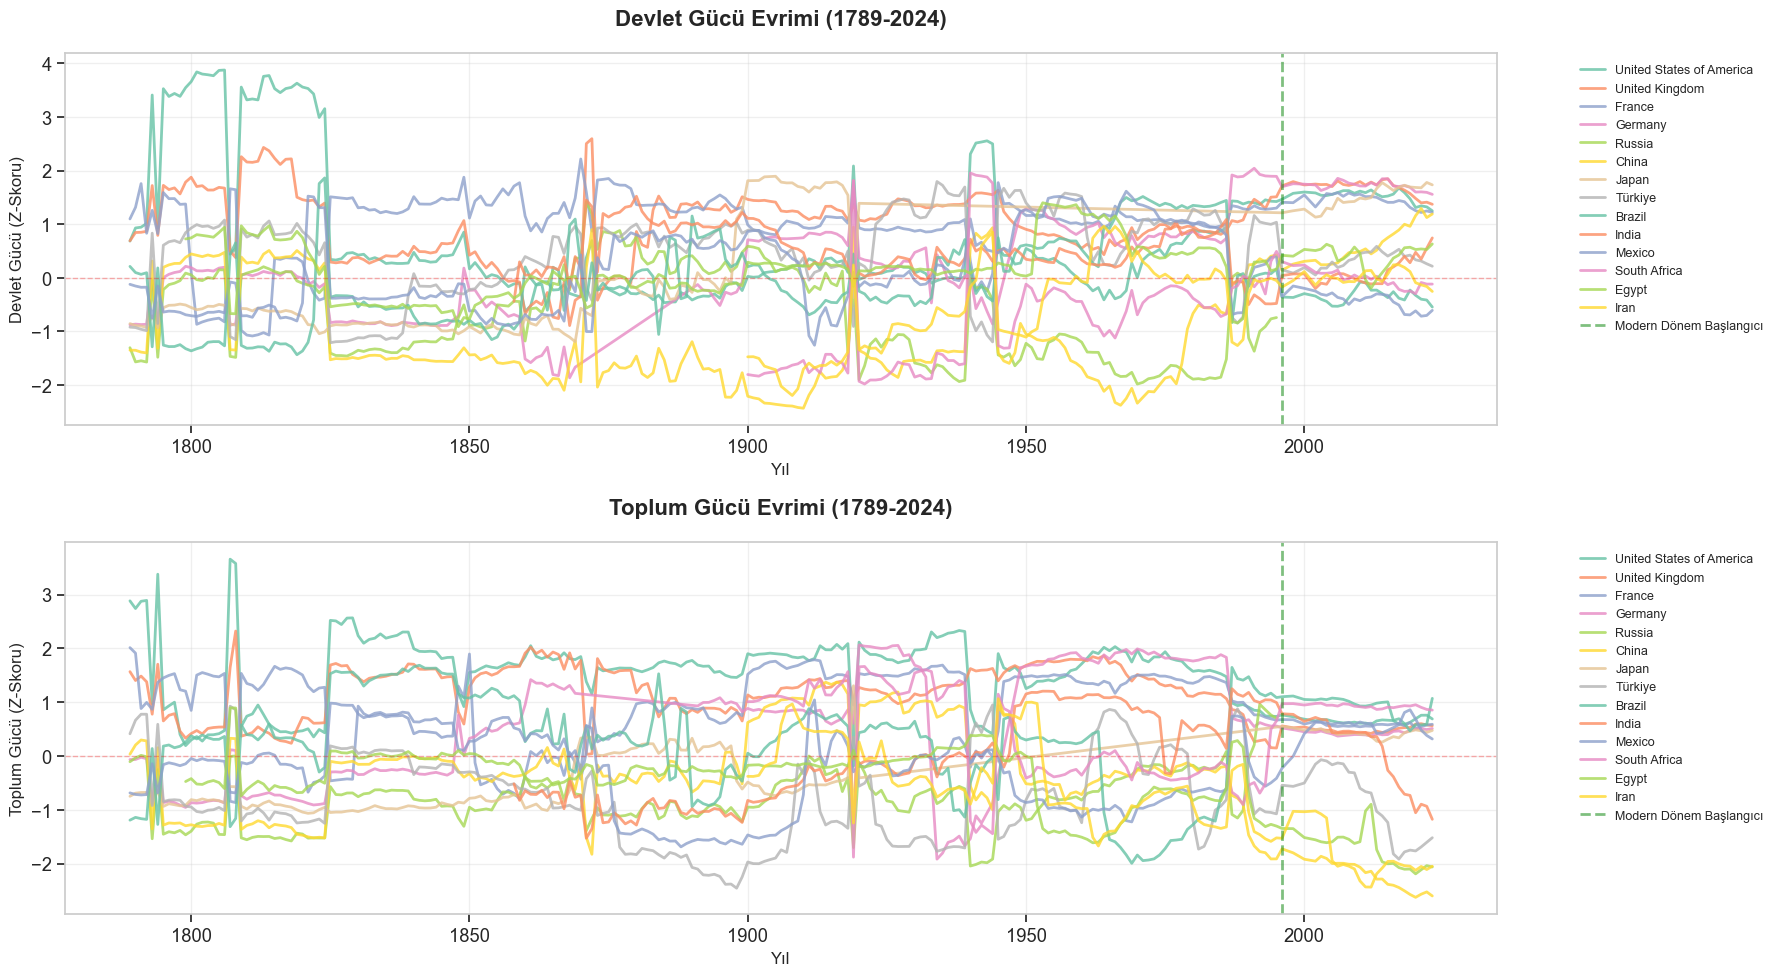

✓ Tarihi trend grafikleri oluşturuldu


In [6]:
# İlginç ülkeler seç
countries_of_interest = [
    'United States of America', 'United Kingdom', 'France', 'Germany',
    'Russia', 'China', 'Japan', 'Türkiye', 'Brazil', 'India',
    'Mexico', 'South Africa', 'Egypt', 'Iran'
]

# Mevcut ülkeleri filtrele
available = [c for c in countries_of_interest if c in df_combined['country_name'].values]

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

for country in available:
    data = df_combined[df_combined['country_name'] == country].sort_values('year')
    
    # Devlet gücü heatmap
    axes[0].plot(data['year'], data['StatePower'], label=country, linewidth=2, alpha=0.8)
    
    # Toplum gücü heatmap
    axes[1].plot(data['year'], data['SocietyPower'], label=country, linewidth=2, alpha=0.8)

# Devlet gücü
axes[0].set_title('Devlet Gücü Evrimi (1789-2024)', fontsize=16, fontweight='bold', pad=20)
axes[0].set_xlabel('Yıl', fontsize=12)
axes[0].set_ylabel('Devlet Gücü (Z-Skoru)', fontsize=12)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.3, linewidth=1)
axes[0].axvline(1996, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Modern Dönem Başlangıcı')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Toplum gücü
axes[1].set_title('Toplum Gücü Evrimi (1789-2024)', fontsize=16, fontweight='bold', pad=20)
axes[1].set_xlabel('Yıl', fontsize=12)
axes[1].set_ylabel('Toplum Gücü (Z-Skoru)', fontsize=12)
axes[1].axhline(0, color='red', linestyle='--', alpha=0.3, linewidth=1)
axes[1].axvline(1996, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Modern Dönem Başlangıcı')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Tarihi trend grafikleri oluşturuldu")

## 6. 📊 Görselleştirme 2: Animasyonlu Dar Koridor

Seçili yıllar için dar koridor grafiğinin animasyonu (interaktif)

In [7]:
# Seçili yıllar (10 yıl aralıklarla)
animation_years = list(range(1800, 2025, 10))
animation_data = df_combined[df_combined['year'].isin(animation_years)].copy()

# Renk paleti
color_map = {
    'Shackled': '#2ecc71',
    'Despotic': '#e74c3c',
    'Paper': '#f39c12',
    'Absent': '#9b59b6'
}

animation_data['Color'] = animation_data['LeviathanType'].map(color_map)

# Plotly animasyonlu scatter
fig = px.scatter(
    animation_data,
    x='SocietyPower',
    y='StatePower',
    animation_frame='year',
    animation_group='country_name',
    color='LeviathanType',
    hover_name='country_name',
    hover_data={'StatePower': ':.2f', 'SocietyPower': ':.2f'},
    color_discrete_map=color_map,
    range_x=[-3, 3],
    range_y=[-3, 3],
    title='Dar Koridor Animasyonu (1800-2024)',
    labels={'StatePower': 'Devlet Gücü', 'SocietyPower': 'Toplum Gücü'}
)

# Dar koridor çizgileri
x_line = np.linspace(-3, 3, 50)
fig.add_trace(go.Scatter(x=x_line, y=x_line + 0.5, mode='lines',
                         line=dict(color='black', dash='dash', width=2),
                         name='Dar Koridor', showlegend=False))
fig.add_trace(go.Scatter(x=x_line, y=x_line - 0.5, mode='lines',
                         line=dict(color='black', dash='dash', width=2),
                         showlegend=False))

# Eksen çizgileri
fig.add_hline(y=0, line_dash="solid", line_color="gray", opacity=0.3)
fig.add_vline(x=0, line_dash="solid", line_color="gray", opacity=0.3)

fig.update_layout(width=900, height=700, hovermode='closest')
fig.show()

print("✓ Animasyonlu görselleştirme oluşturuldu")

✓ Animasyonlu görselleştirme oluşturuldu


## 7. 📊 Görselleştirme 3: Türkiye Detaylı Analiz

Türkiye'nin 235 yıllık dar koridor yolculuğu

In [8]:
# Türkiye verisi
turkey_data = df_combined[df_combined['country_name'] == 'Türkiye'].sort_values('year').copy()

if len(turkey_data) > 0:
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            'Devlet Gücü (Zaman Serisi)',
            'Toplum Gücü (Zaman Serisi)',
            'Dar Koridor Hareketi',
            'Leviathan Tipi Dağılımı'
        ),
        specs=[[{'type': 'scatter'}, {'type': 'scatter'}],
               [{'type': 'scatter'}, {'type': 'bar'}]]
    )
    
    # 1. Devlet gücü zaman serisi
    fig.add_trace(
        go.Scatter(x=turkey_data['year'], y=turkey_data['StatePower'],
                   mode='lines+markers', name='Devlet Gücü',
                   line=dict(color='#3498db', width=2)),
        row=1, col=1
    )
    fig.add_hline(y=0, line_dash="dash", line_color="red", opacity=0.3, row=1, col=1)
    
    # 2. Toplum gücü zaman serisi
    fig.add_trace(
        go.Scatter(x=turkey_data['year'], y=turkey_data['SocietyPower'],
                   mode='lines+markers', name='Toplum Gücü',
                   line=dict(color='#e74c3c', width=2)),
        row=1, col=2
    )
    fig.add_hline(y=0, line_dash="dash", line_color="red", opacity=0.3, row=1, col=2)
    
    # 3. Dar koridor hareketi
    fig.add_trace(
        go.Scatter(x=turkey_data['SocietyPower'], y=turkey_data['StatePower'],
                   mode='markers+lines', name='Hareket',
                   marker=dict(size=8, color=turkey_data['year'],
                              colorscale='Viridis', showscale=True,
                              colorbar=dict(title="Yıl", x=1.15)),
                   text=turkey_data['year'],
                   hovertemplate='Yıl: %{text}<br>Toplum: %{x:.2f}<br>Devlet: %{y:.2f}'),
        row=2, col=1
    )
    
    # Dar koridor çizgileri
    x_corr = np.linspace(-3, 3, 50)
    fig.add_trace(
        go.Scatter(x=x_corr, y=x_corr + 0.5, mode='lines',
                   line=dict(color='black', dash='dash'), showlegend=False),
        row=2, col=1
    )
    fig.add_trace(
        go.Scatter(x=x_corr, y=x_corr - 0.5, mode='lines',
                   line=dict(color='black', dash='dash'), showlegend=False),
        row=2, col=1
    )
    
    # 4. Leviathan tipi dağılımı
    type_counts = turkey_data['LeviathanType'].value_counts()
    fig.add_trace(
        go.Bar(x=type_counts.index, y=type_counts.values,
               marker_color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']),
        row=2, col=2
    )
    
    fig.update_xaxes(title_text="Yıl", row=1, col=1)
    fig.update_xaxes(title_text="Yıl", row=1, col=2)
    fig.update_xaxes(title_text="Toplum Gücü", row=2, col=1)
    fig.update_xaxes(title_text="Leviathan Tipi", row=2, col=2)
    
    fig.update_yaxes(title_text="Devlet Gücü", row=1, col=1)
    fig.update_yaxes(title_text="Toplum Gücü", row=1, col=2)
    fig.update_yaxes(title_text="Devlet Gücü", row=2, col=1)
    fig.update_yaxes(title_text="Yıl Sayısı", row=2, col=2)
    
    fig.update_layout(
        title_text="Türkiye - Dar Koridor Detaylı Analiz (1789-2024)",
        showlegend=False,
        height=800,
        width=1200
    )
    
    fig.show()
    
    print("✓ Türkiye detaylı analizi oluşturuldu")
else:
    print("⚠️ Türkiye verisi bulunamadı")

✓ Türkiye detaylı analizi oluşturuldu


## 8. 📊 Görselleştirme 4: Yıllara Göre Ülke Sayısı ve Dağılım

Veri kapsamının tarihi değişimi

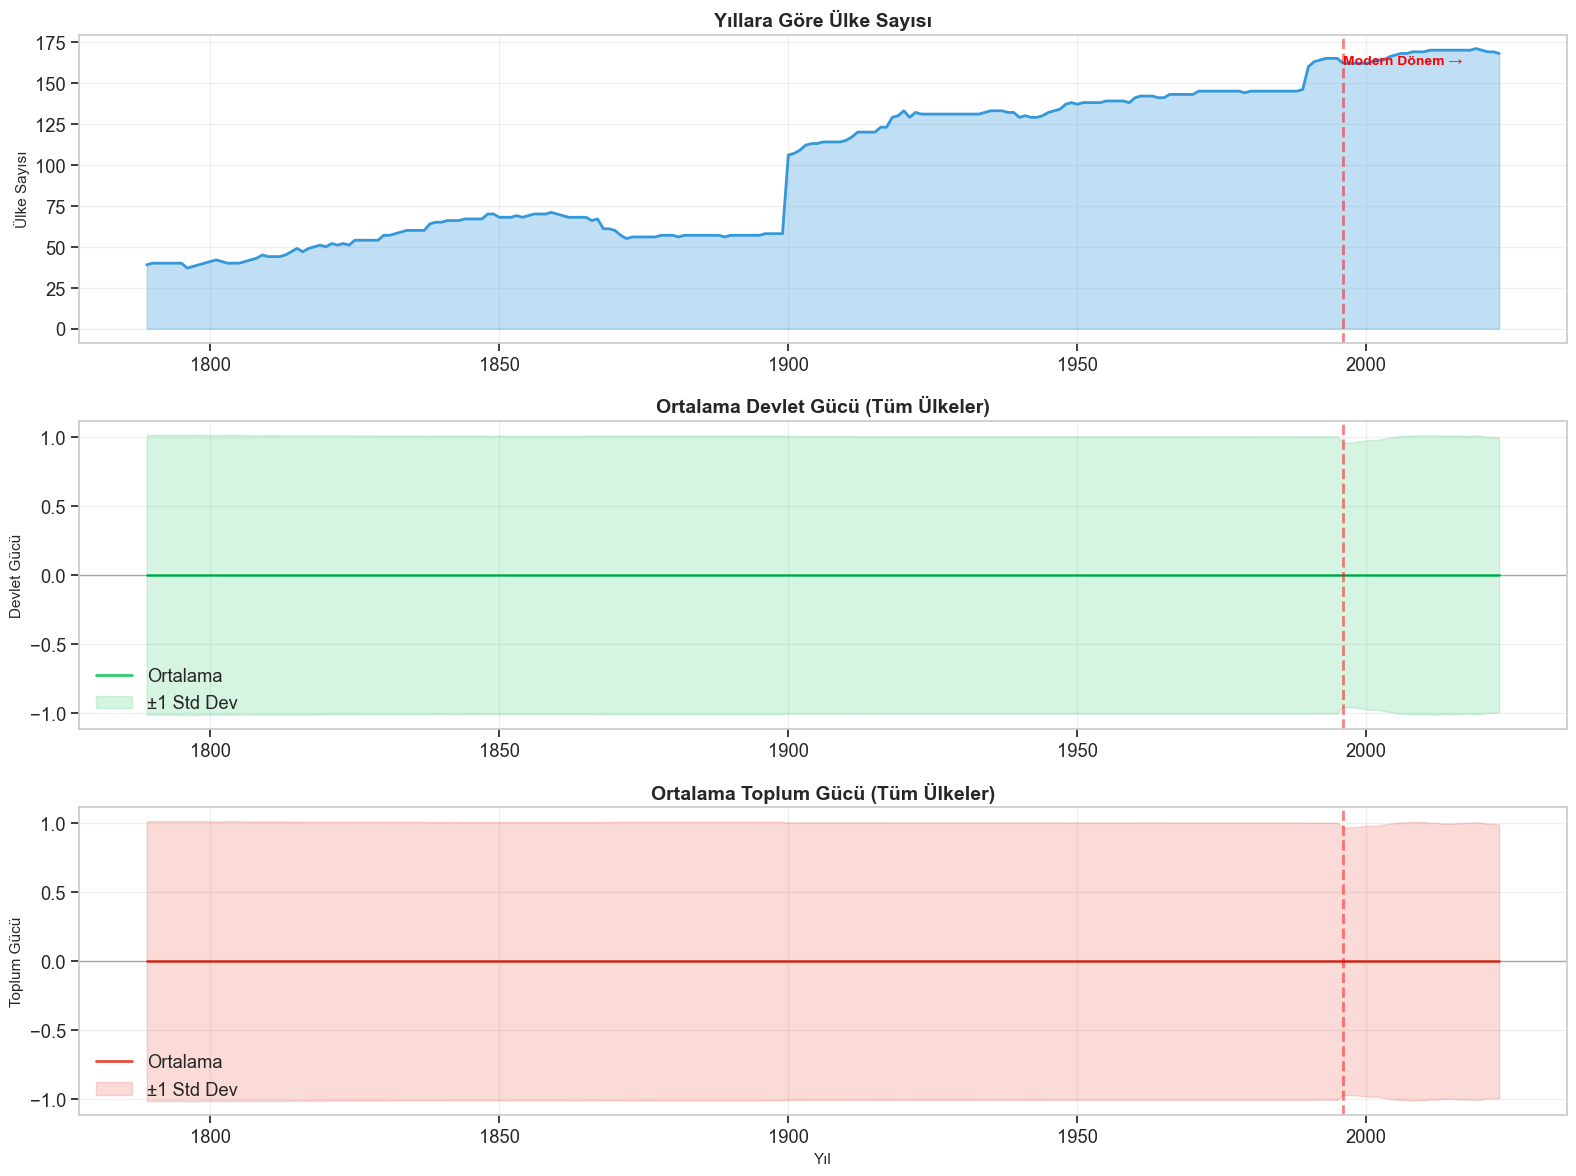

✓ Yıllık istatistik grafikleri oluşturuldu


In [9]:
# Yıl bazında istatistikler
year_stats = df_combined.groupby('year').agg({
    'country_name': 'nunique',
    'StatePower': ['mean', 'std'],
    'SocietyPower': ['mean', 'std']
}).reset_index()

year_stats.columns = ['year', 'n_countries', 'state_mean', 'state_std', 'society_mean', 'society_std']

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Ülke sayısı
axes[0].fill_between(year_stats['year'], year_stats['n_countries'], alpha=0.3, color='#3498db')
axes[0].plot(year_stats['year'], year_stats['n_countries'], linewidth=2, color='#3498db')
axes[0].axvline(1996, color='red', linestyle='--', alpha=0.5, linewidth=2)
axes[0].set_title('Yıllara Göre Ülke Sayısı', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Ülke Sayısı', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].text(1996, axes[0].get_ylim()[1]*0.9, 'Modern Dönem →', 
             fontsize=10, color='red', fontweight='bold')

# 2. Ortalama devlet gücü
axes[1].plot(year_stats['year'], year_stats['state_mean'], linewidth=2, color='#2ecc71', label='Ortalama')
axes[1].fill_between(year_stats['year'],
                     year_stats['state_mean'] - year_stats['state_std'],
                     year_stats['state_mean'] + year_stats['state_std'],
                     alpha=0.2, color='#2ecc71', label='±1 Std Dev')
axes[1].axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=1)
axes[1].axvline(1996, color='red', linestyle='--', alpha=0.5, linewidth=2)
axes[1].set_title('Ortalama Devlet Gücü (Tüm Ülkeler)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Devlet Gücü', fontsize=11)
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

# 3. Ortalama toplum gücü
axes[2].plot(year_stats['year'], year_stats['society_mean'], linewidth=2, color='#e74c3c', label='Ortalama')
axes[2].fill_between(year_stats['year'],
                     year_stats['society_mean'] - year_stats['society_std'],
                     year_stats['society_mean'] + year_stats['society_std'],
                     alpha=0.2, color='#e74c3c', label='±1 Std Dev')
axes[2].axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=1)
axes[2].axvline(1996, color='red', linestyle='--', alpha=0.5, linewidth=2)
axes[2].set_title('Ortalama Toplum Gücü (Tüm Ülkeler)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Yıl', fontsize=11)
axes[2].set_ylabel('Toplum Gücü', fontsize=11)
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Yıllık istatistik grafikleri oluşturuldu")

## 9. 💾 Veri Eksportu

Birleştirilmiş veriyi CSV ve JSON formatlarında kaydediyoruz.

In [10]:
# CSV eksportu
output_csv = '/Users/metincatal/Desktop/ATLAS-Interaktif/data/processed/vdem_historical/dar_koridor_combined_1789_2024.csv'
df_combined.to_csv(output_csv, index=False)

print(f"✓ CSV kaydedildi: {output_csv}")
print(f"  Toplam {len(df_combined):,} gözlem")
print(f"  Yıl aralığı: {df_combined['year'].min()}-{df_combined['year'].max()}")
print(f"  Ülke sayısı: {df_combined['country_name'].nunique()}")

✓ CSV kaydedildi: /Users/metincatal/Desktop/ATLAS-Interaktif/data/processed/vdem_historical/dar_koridor_combined_1789_2024.csv
  Toplam 23,345 gözlem
  Yıl aralığı: 1789-2023
  Ülke sayısı: 208


In [12]:
# JSON eksportu (web uygulaması için)
json_output = {
    'metadata': {
        'title': 'Dar Koridor Tarihi Analiz 1789-2024',
        'year_range': [int(df_combined['year'].min()), int(df_combined['year'].max())],
        'total_countries': int(df_combined['country_name'].nunique()),
        'total_observations': int(len(df_combined)),
        'data_sources': {
            'historical': 'V-Dem only (1789-1996)',
            'modern': 'WGI + V-Dem combined (1996-2024)'
        },
        'created_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    },
    'years': {}
}

# Her yıl için veri
for year in sorted(df_combined['year'].unique()):
    df_year = df_combined[df_combined['year'] == year]
    
    json_output['years'][str(int(year))] = [
        {
            'name': row['country_name'],
            'statePower': round(float(row['StatePower']), 3),
            'societyPower': round(float(row['SocietyPower']), 3),
            'leviathanType': row['LeviathanType'],
            'cluster': int(row['Cluster'])
        }
        for _, row in df_year.iterrows()
    ]

# JSON kaydet
output_json = '/Users/metincatal/Desktop/ATLAS-Interaktif/data/processed/vdem_historical/dar_koridor_combined_all_years.json'
with open(output_json, 'w', encoding='utf-8') as f:
    json.dump(json_output, f, ensure_ascii=False, indent=2)

print(f"\n✓ JSON kaydedildi: {output_json}")
print(f"  {len(json_output['years'])} yıl")
print(f"  İlk yıl: {min(json_output['years'].keys())} ({len(json_output['years'][min(json_output['years'].keys())])} ülke)")
print(f"  Son yıl: {max(json_output['years'].keys())} ({len(json_output['years'][max(json_output['years'].keys())])} ülke)")


✓ JSON kaydedildi: /Users/metincatal/Desktop/ATLAS-Interaktif/data/processed/vdem_historical/dar_koridor_combined_all_years.json
  232 yıl
  İlk yıl: 1789 (39 ülke)
  Son yıl: 2023 (168 ülke)


## 10. 📈 Özet Rapor

Analiz sonuçlarının kapsamlı özeti

In [13]:
print("="*80)
print("DAR KORİDOR TARİHİ ANALİZ RAPORU (1789-2024)")
print("="*80)

print(f"\n📊 VERİ KAPSAMI:")
print(f"  • Toplam süre: {df_combined['year'].max() - df_combined['year'].min() + 1} yıl")
print(f"  • Yıl aralığı: {df_combined['year'].min()}-{df_combined['year'].max()}")
print(f"  • Toplam gözlem: {len(df_combined):,}")
print(f"  • Toplam ülke: {df_combined['country_name'].nunique()}")

print(f"\n🔍 DÖNEMSEL DAĞILIM:")
print(f"  Tarihi Dönem (1789-1996):")
print(f"    • Gözlem: {len(df_historical):,}")
print(f"    • Ülke: {df_historical['country_name'].nunique()}")
print(f"    • Veri kaynağı: V-Dem (17 gösterge)")
print(f"  Modern Dönem (1996-2024):")
print(f"    • Gözlem: {len(modern_renamed):,}")
print(f"    • Ülke: {modern_renamed['country_name'].nunique()}")
print(f"    • Veri kaynağı: WGI + V-Dem kombinasyonu")

print(f"\n🎯 LEVİATHAN TİPİ DAĞILIMI (Tüm Dönem):")
type_counts = df_combined['LeviathanType'].value_counts()
for lev_type in ['Shackled', 'Despotic', 'Paper', 'Absent']:
    if lev_type in type_counts.index:
        count = type_counts[lev_type]
        pct = count / len(df_combined) * 100
        print(f"  • {lev_type:<12}: {count:>6,} gözlem ({pct:>5.1f}%)")

print(f"\n📈 TEMEL İSTATİSTİKLER:")
print(f"  Devlet Gücü:")
print(f"    • Ortalama: {df_combined['StatePower'].mean():>6.3f}")
print(f"    • Std Sapma: {df_combined['StatePower'].std():>6.3f}")
print(f"    • Min-Max: [{df_combined['StatePower'].min():>6.3f}, {df_combined['StatePower'].max():>6.3f}]")
print(f"  Toplum Gücü:")
print(f"    • Ortalama: {df_combined['SocietyPower'].mean():>6.3f}")
print(f"    • Std Sapma: {df_combined['SocietyPower'].std():>6.3f}")
print(f"    • Min-Max: [{df_combined['SocietyPower'].min():>6.3f}, {df_combined['SocietyPower'].max():>6.3f}]")

print(f"\n✅ ÇIKTILAR:")
print(f"  • CSV: {output_csv}")
print(f"  • JSON: {output_json}")

print("\n" + "="*80)
print("🎉 Analiz başarıyla tamamlandı!")
print("="*80)

DAR KORİDOR TARİHİ ANALİZ RAPORU (1789-2024)

📊 VERİ KAPSAMI:
  • Toplam süre: 235 yıl
  • Yıl aralığı: 1789-2023
  • Toplam gözlem: 23,345
  • Toplam ülke: 208

🔍 DÖNEMSEL DAĞILIM:
  Tarihi Dönem (1789-1996):
    • Gözlem: 19,148
    • Ülke: 187
    • Veri kaynağı: V-Dem (17 gösterge)
  Modern Dönem (1996-2024):
    • Gözlem: 4,197
    • Ülke: 173
    • Veri kaynağı: WGI + V-Dem kombinasyonu

🎯 LEVİATHAN TİPİ DAĞILIMI (Tüm Dönem):
  • Shackled    :  5,908 gözlem ( 25.3%)
  • Despotic    :  5,932 gözlem ( 25.4%)
  • Paper       :  6,418 gözlem ( 27.5%)
  • Absent      :  5,087 gözlem ( 21.8%)

📈 TEMEL İSTATİSTİKLER:
  Devlet Gücü:
    • Ortalama: -0.000
    • Std Sapma:  0.999
    • Min-Max: [-3.541,  3.876]
  Toplum Gücü:
    • Ortalama:  0.000
    • Std Sapma:  0.999
    • Min-Max: [-2.899,  3.661]

✅ ÇIKTILAR:
  • CSV: /Users/metincatal/Desktop/ATLAS-Interaktif/data/processed/vdem_historical/dar_koridor_combined_1789_2024.csv
  • JSON: /Users/metincatal/Desktop/ATLAS-Interaktif/data